<a href="https://colab.research.google.com/github/rutwikdaware05/NNDL_Lab/blob/main/P3_NNDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Implement a Feed-Forward Neural Network for MNIST

First, we will import the necessary libraries and load the MNIST dataset. The MNIST dataset consists of 60,000 training images and 10,000 test images of handwritten digits.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Shape of x_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of x_test: (10000, 28, 28)
Shape of y_test: (10000,)


Next, we need to preprocess the data. This involves:
1.  **Normalizing pixel values**: Scaling image pixel values from [0, 255] to [0, 1].
2.  **Reshaping images**: Flattening the 28x28 images into a 1D vector of 784 pixels.
3.  **One-hot encoding labels**: Converting integer labels (0-9) into a binary vector format.

In [ ]:
# Normalize pixel values to be between 0 and 1
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Reshape images to 1D vectors
x_train = x_train.reshape(-1, 28 * 28) # 60000 images, each 784 pixels
x_test = x_test.reshape(-1, 28 * 28) # 10000 images, each 784 pixels

# Convert labels to one-hot encoding
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print(f"Shape of x_train after preprocessing: {x_train.shape}")
print(f"Shape of y_train after preprocessing: {y_train.shape}")

Shape of x_train after preprocessing: (60000, 784)
Shape of y_train after preprocessing: (60000, 10)


Now, we will build the feed-forward neural network model. We will use a `Sequential` model with three `Dense` layers:
1.  An input layer with 256 neurons and ReLU activation.
2.  A hidden layer with 128 neurons and ReLU activation.
3.  An output layer with 10 neurons (for 10 classes) and softmax activation.

In [ ]:
model = keras.Sequential([
    keras.Input(shape=(784,)), # Input layer, 784 features (28*28 pixels)
    layers.Dense(256, activation="relu"), # First hidden layer with 256 neurons
    layers.Dense(128, activation="relu"), # Second hidden layer with 128 neurons
    layers.Dense(num_classes, activation="softmax"), # Output layer with 10 neurons for 10 classes
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Next, we compile the model. We'll use:
-   **Optimizer**: Adam
-   **Loss function**: Categorical cross-entropy (suitable for multi-class classification with one-hot encoded labels)
-   **Metrics**: Accuracy

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

Now, we will train the model using the training data. We'll train for 10 epochs with a batch size of 128.

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9812 - loss: 0.0591 - val_accuracy: 0.9743 - val_loss: 0.0999
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9896 - loss: 0.0302 - val_accuracy: 0.9718 - val_loss: 0.1144
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9908 - loss: 0.0269 - val_accuracy: 0.9758 - val_loss: 0.1030
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9925 - loss: 0.0221 - val_accuracy: 0.9795 - val_loss: 0.0966
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9935 - loss: 0.0191 - val_accuracy: 0.9793 - val_loss: 0.0987
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9938 - loss: 0.0183 - val_accuracy: 0.9773 - val_loss: 0.0984
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9944 - loss: 0.0175 - val_accuracy: 0.9780 - val_loss: 0.1021
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9963 - loss: 0.0

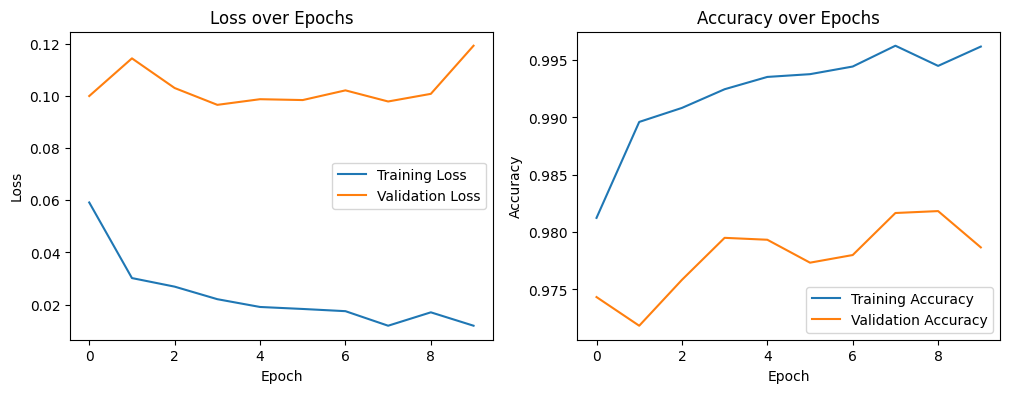

In [ ]:
batch_size = 32
epochs = 10

history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

# Plot training history (loss and accuracy)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Finally, we evaluate the trained model on the test dataset to see its performance on unseen data.

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.0972
Test Accuracy: 0.9772


### Visualize Predictions

Let's visualize some of the predictions made by the model. We'll pick a few random images from the test set and display their actual label versus the predicted label.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


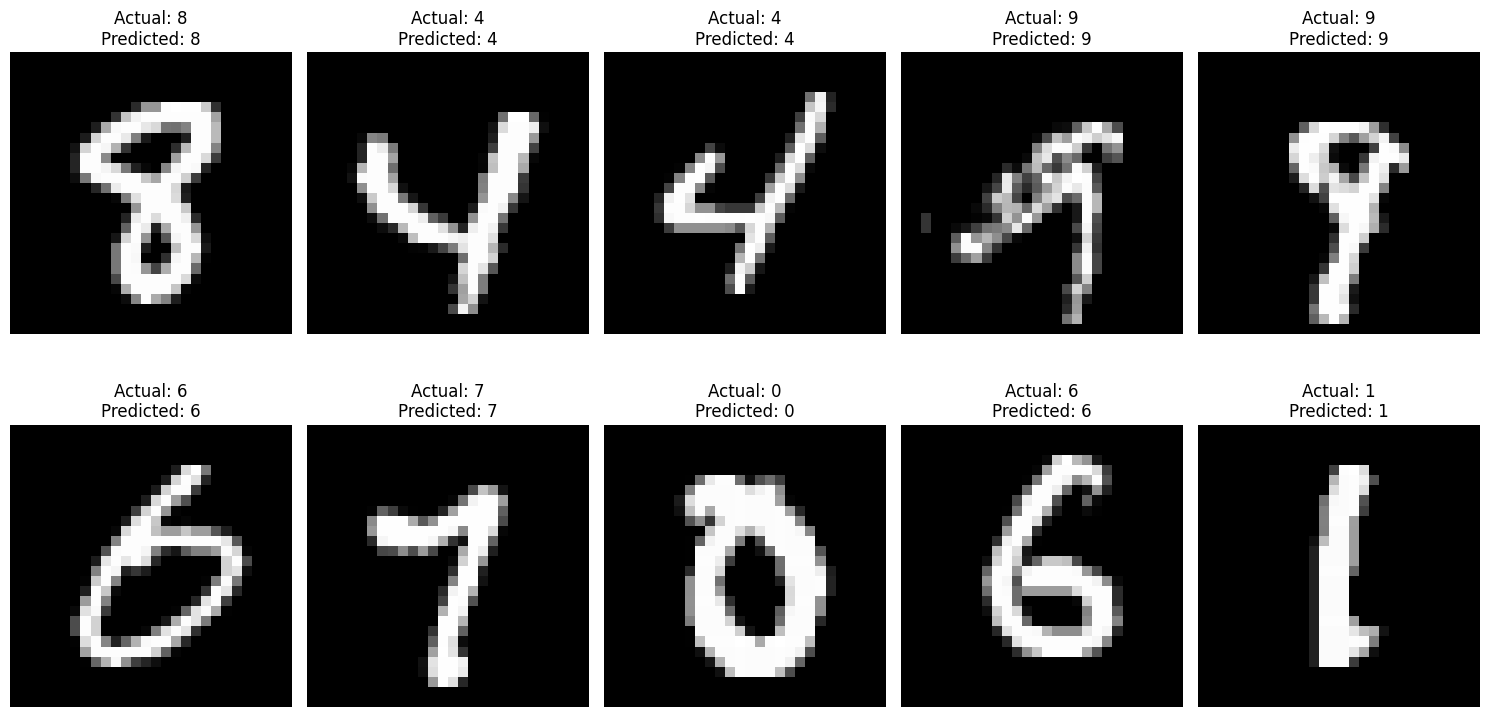

In [ ]:
# Make predictions on the test set
predictions = model.predict(x_test)

# Convert one-hot encoded labels back to integers for easy comparison
y_test_labels = np.argmax(y_test, axis=1)
predicted_labels = np.argmax(predictions, axis=1)

# Reshape x_test back to original image shape for plotting
x_test_images = x_test.reshape(-1, 28, 28)

# Select a few random indices to display
num_samples = 10
random_indices = np.random.choice(len(x_test_images), num_samples, replace=False)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_images[idx], cmap='gray')
    plt.title(f"Actual: {y_test_labels[idx]}\nPredicted: {predicted_labels[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()